In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

#### Load data

In [50]:
df = pd.read_csv("camelyon16_model_results_new.csv")

In [44]:
df.head()

,Model,Pre-processor,mean_acc,mean_bacc,mean_macro-auc,mean_macro-f1,std_acc,std_bacc,std_macro-auc,std_macro-f1
0,MEAN_MIL,CLAM,64.500,60.224,60.330,60.092,2.319828,0.475378,1.004510,0.543227
1,MEAN_MIL,TRIDENT,53.022,54.848,53.514,52.784,0.789567,0.855953,0.420837,0.582361
2,MEAN_MIL,HISTOLAB,66.358,58.242,53.800,56.228,0.382120,0.505427,0.930312,1.056189
3,MEAN_MIL,MUFASA,68.068,62.528,62.312,63.618,1.582042,0.905349,0.978047,2.325626
4,DEEPATTN_MIL,CLAM,57.204,50.000,67.750,36.120,9.612000,0.000000,1.142296,4.300000


#### Pivot for paired comparison

In [45]:
pivot_auc = df.pivot(
    index="Model",
    columns="Pre-processor",
    values="mean_macro-f1"
)

pivot_auc

Pre-processor,CLAM,HISTOLAB,MUFASA,TRIDENT
Model,,,,
AC_MIL,79.092,78.5780,80.042,77.416
ADD_MIL,77.972,77.3840,77.306,64.808
CLAM-MB,79.768,76.5500,82.150,77.380
DEEPATTN_MIL,36.120,36.1200,38.270,33.970
DGR_MIL,73.264,69.1820,75.446,54.906
DS_MIL,68.096,59.8700,71.312,61.586
DTFD-MIL,79.604,76.4360,83.010,74.874
MAMBA-MIL,84.532,83.7080,84.746,84.540
MEAN_MIL,60.092,56.2280,63.618,52.784


#### Compute ΔAUC (paired)

In [46]:
delta_auc = pd.DataFrame({
    "MUFASA_vs_CLAM": pivot_auc["MUFASA"] - pivot_auc["CLAM"],
    "MUFASA_vs_TRIDENT": pivot_auc["MUFASA"] - pivot_auc["TRIDENT"],
    "MUFASA_vs_HISTOLAB": pivot_auc["MUFASA"] - pivot_auc["HISTOLAB"],
})

delta_auc

,MUFASA_vs_CLAM,MUFASA_vs_TRIDENT,MUFASA_vs_HISTOLAB
Model,,,
AC_MIL,0.950,2.626,1.4640
ADD_MIL,-0.666,12.498,-0.0780
CLAM-MB,2.382,4.770,5.6000
DEEPATTN_MIL,2.150,4.300,2.1500
DGR_MIL,2.182,20.540,6.2640
DS_MIL,3.216,9.726,11.4420
DTFD-MIL,3.406,8.136,6.5740
MAMBA-MIL,0.214,0.206,1.0380
MEAN_MIL,3.526,10.834,7.3900


#### Wilcoxon signed-rank tests

In [47]:
results = {}

for col in delta_auc.columns:
    values = delta_auc[col].dropna()
    if len(values) > 1:
        stat, p = wilcoxon(values)
    else:
        stat, p = np.nan, np.nan  # not enough samples

    results[col] = {
        "median_delta_auc": np.median(values),
        "p_value": p
    }

pd.DataFrame(results).T

,median_delta_auc,p_value
MUFASA_vs_CLAM,2.282,0.000366
MUFASA_vs_TRIDENT,4.620,0.000122
MUFASA_vs_HISTOLAB,3.875,0.000244


#### Plot ΔAUC distribution

/tmp/ipykernel_707951/1121434755.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


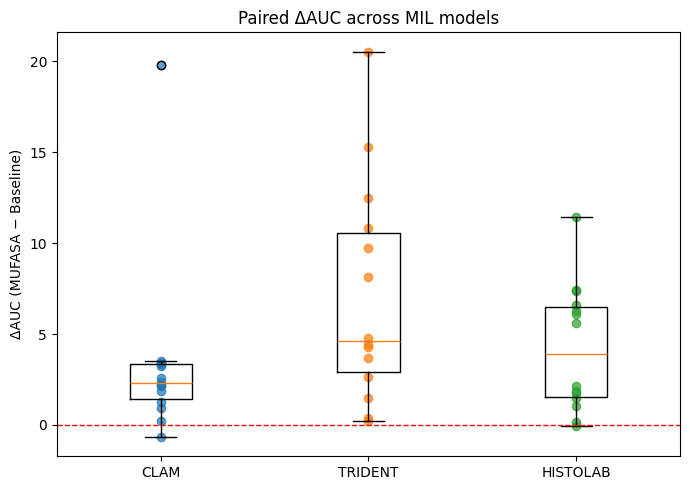

In [48]:
fig, ax = plt.subplots(figsize=(7, 5))

data_to_plot = [
    delta_auc["MUFASA_vs_CLAM"],
    delta_auc["MUFASA_vs_TRIDENT"],
    delta_auc["MUFASA_vs_HISTOLAB"],
]

ax.boxplot(
    data_to_plot,
    labels=["CLAM", "TRIDENT", "HISTOLAB"],
    showfliers=True
)

# Scatter individual points
for i, vals in enumerate(data_to_plot, start=1):
    ax.scatter(
        np.full(len(vals), i),
        vals,
        alpha=0.7
    )

ax.axhline(0, linestyle="--", color="red", linewidth=1)

ax.set_ylabel("ΔAUC (MUFASA − Baseline)")
ax.set_title("Paired ΔAUC across MIL models")

plt.tight_layout()
plt.show()


#### Creating a single figure

/tmp/ipykernel_3814963/3595002151.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/home/rajaj/anaconda3/envs/Tiles/lib/python3.9/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_3814963/3595002151.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3814963/3595002151.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3814963/3595002151.py:58:

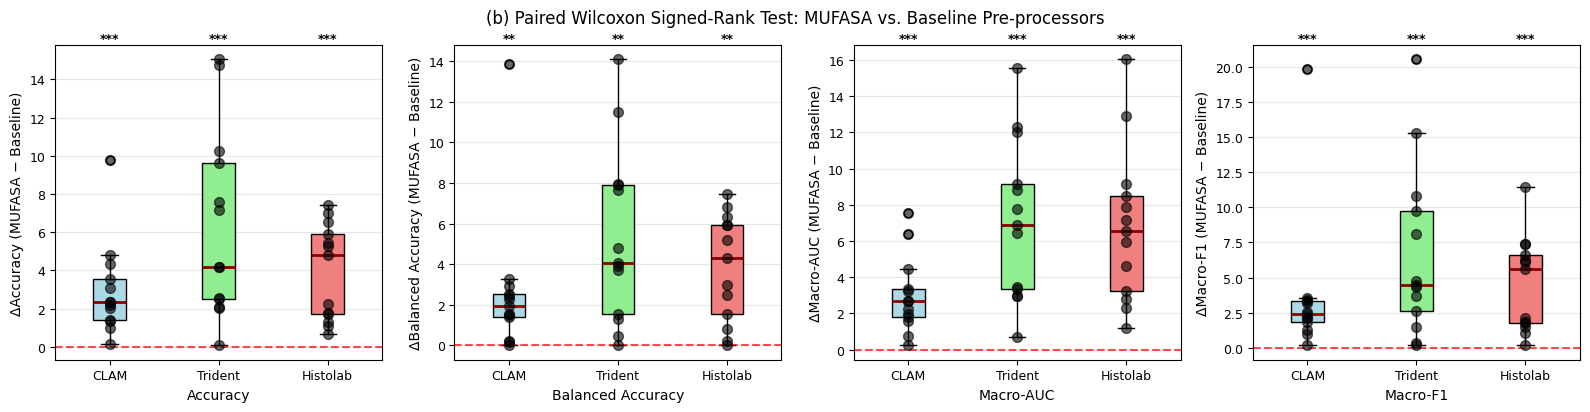


WILCOXON SIGNED-RANK TEST RESULTS

ACCURACY (mean_acc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Median Δ: 2.3260
    p-value:  2.4414e-04
    Significance: *** (p < 0.001)
  MUFASA vs. Trident:
    Median Δ: 4.1900
    p-value:  2.4414e-04
    Significance: *** (p < 0.001)
  MUFASA vs. Histolab:
    Median Δ: 4.8060
    p-value:  2.4414e-04
    Significance: *** (p < 0.001)

BALANCED ACCURACY (mean_bacc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Median Δ: 1.9480
    p-value:  2.2177e-03
    Significance: ** (p < 0.01)
  MUFASA vs. Trident:
    Median Δ: 4.0820
    p-value:  2.2177e-03
    Significance: ** (p < 0.01)
  MUFASA vs. Histolab:
    Median Δ: 4.2860
    p-value:  2.2177e-03
    Significance: ** (p < 0.01)

MACRO-AUC (mean_macro-auc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Median Δ: 2.6640
    p-value:  2.4414e-04
    Significance: *** (p < 0.001

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

df = pd.read_csv("Camelyon16_Model_Results.csv")

# Define metrics to analyze
metrics = ["mean_acc", "mean_bacc", "mean_macro-auc", "mean_macro-f1"]
metric_labels = ["Accuracy", "Balanced Accuracy", "Macro-AUC", "Macro-F1"]

# Create figure with subplots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Store all results
all_results = {}

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    
    # Pivot data for current metric
    pivot_metric = df.pivot(
        index="Model",
        columns="Pre-processor",
        values=metric
    )
    
    # Calculate deltas
    delta_metric = pd.DataFrame({
        "MUFASA_vs_CLAM": pivot_metric["MUFASA"] - pivot_metric["CLAM"],
        "MUFASA_vs_Trident": pivot_metric["MUFASA"] - pivot_metric["TRIDENT"],
        "MUFASA_vs_Histolab": pivot_metric["MUFASA"] - pivot_metric["HISTOLAB"],
    })
    
    # Statistical tests
    results = {}
    for col in delta_metric.columns:
        values = delta_metric[col].dropna()
        if len(values) > 1:
            stat, p = wilcoxon(values)
        else:
            stat, p = np.nan, np.nan
        results[col] = {
            "median_delta": np.median(values),
            "p_value": p
        }
    
    all_results[metric] = results
    
    # Prepare data for plotting
    data_to_plot = [
        delta_metric["MUFASA_vs_CLAM"],
        delta_metric["MUFASA_vs_Trident"],
        delta_metric["MUFASA_vs_Histolab"],
    ]
    
    # Create boxplot
    bp = ax.boxplot(
        data_to_plot,
        labels=["CLAM", "Trident", "Histolab"],
        showfliers=True,
        patch_artist=True,
        medianprops=dict(color='darkred', linewidth=2)
    )
    
    # Color boxes
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Scatter individual points
    for i, vals in enumerate(data_to_plot, start=1):
        ax.scatter(
            np.full(len(vals), i),
            vals,
            alpha=0.6,
            s=50,
            color='black',
            zorder=3
        )
    
    # Add horizontal line at 0
    ax.axhline(0, linestyle="--", color="red", linewidth=1.5, alpha=0.7)
    
    # Labels and formatting
    ax.set_ylabel(f"Δ{label} (MUFASA − Baseline)", fontsize=10)
    ax.set_xlabel(f"{label}", fontsize=10)
    # ax.set_title(label, fontsize=11, fontweight='normal')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Adjust tick label sizes
    ax.tick_params(axis='both', which='major', labelsize=9) 
    
    # Adjust p-value annotations to be just slightly above the figure
    y_max = max([v.max() for v in data_to_plot])
    y_range = y_max - min([v.min() for v in data_to_plot])
    
    for i, col in enumerate(delta_metric.columns, start=1):
        p_val = results[col]["p_value"]
        if not np.isnan(p_val):
            sig_marker = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            ax.text(i, y_max + 0.05 * y_range, sig_marker, 
                   ha='center', va='bottom', 
                   fontsize=9,
                   fontweight='bold',
                   color='black')

plt.tight_layout()

# Add overall figure title
fig.suptitle("(b) Paired Wilcoxon Signed-Rank Test: MUFASA vs. Baseline Pre-processors", 
             fontsize=12, fontweight='normal', y=1.02)

plt.savefig("Camelyon16_Wilcoxon_comparison_all_metrics.png", 
            dpi=400, 
            bbox_inches='tight', 
            pad_inches=0.1)
plt.show()

# Print statistical results
print("\n" + "="*80)
print("WILCOXON SIGNED-RANK TEST RESULTS")
print("="*80)

for metric, label in zip(metrics, metric_labels):
    print(f"\n{label.upper()} ({metric}):")
    print("-" * 60)
    for comparison, stats in all_results[metric].items():
        baseline = comparison.split("_vs_")[1]
        print(f"  MUFASA vs. {baseline}:")
        print(f"    Median Δ: {stats['median_delta']:.4f}")
        print(f"    p-value:  {stats['p_value']:.4e}" if not np.isnan(stats['p_value']) else "    p-value:  N/A")
        if not np.isnan(stats['p_value']):
            if stats['p_value'] < 0.001:
                print(f"    Significance: *** (p < 0.001)")
            elif stats['p_value'] < 0.01:
                print(f"    Significance: ** (p < 0.01)")
            elif stats['p_value'] < 0.05:
                print(f"    Significance: * (p < 0.05)")
            else:
                print(f"    Significance: ns (p ≥ 0.05)")

# Generate figure caption
caption = """
Figure X. Paired comparison of MUFASA pre-processor against baseline methods across multiple evaluation metrics. 
Wilcoxon signed-rank tests were performed on paired differences (ΔMUFASA - Baseline) across all MIL models. 
Each box represents the distribution of performance differences, with individual model results shown as scatter points. 
The red dashed line indicates zero difference. Positive values indicate MUFASA outperforms the baseline. 
Statistical significance is indicated above each boxplot: 
*** p < 0.001, ** p < 0.01, * p < 0.05, ns: not significant (p ≥ 0.05).
"""

print("\n" + "="*80)
print("SUGGESTED FIGURE CAPTION:")
print("="*80)
print(caption)

### Final version (used in manuscript)

Calculated Mean and Std for each (Model, Method) combination:
            Model Pre-processor  mean_acc  mean_bacc  mean_macro-auc  mean_macro-f1
0          AC-MIL          CLAM    80.614     78.676          83.856         79.092
1          AC-MIL      Histolab    80.150     78.144          81.890         78.578
2          AC-MIL        MUFASA    81.940     80.624          86.520         80.042
3          AC-MIL       Trident    79.374     76.726          79.616         77.416
4         ADD-MIL          CLAM    79.414     76.298          81.380         77.572
5         ADD-MIL      Histolab    77.864     75.948          80.150         75.184
6         ADD-MIL        MUFASA    80.774     77.890          81.942         78.906
7         ADD-MIL       Trident    78.592     76.398          80.528         76.008
8     CLAM-MB-MIL          CLAM    82.014     78.536          84.114         79.768
9     CLAM-MB-MIL      Histolab    78.752     75.752          79.598         76.550
10    CLAM-MB-

/home/rajaj/anaconda3/envs/Tiles/lib/python3.9/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_4017081/3548048921.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/home/rajaj/anaconda3/envs/Tiles/lib/python3.9/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_4017081/3548048921.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxpl

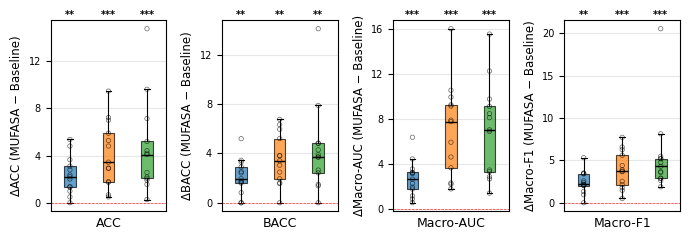


WILCOXON SIGNED-RANK TEST RESULTS

ACC (mean_acc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Median Δ: 2.2040
    p-value:  2.2177e-03
    Significance: ** (p < 0.01)
  MUFASA vs. Trident:
    Median Δ: 4.0880
    p-value:  2.4414e-04
    Significance: *** (p < 0.001)
  MUFASA vs. Histolab:
    Median Δ: 3.4400
    p-value:  2.4414e-04
    Significance: *** (p < 0.001)

BACC (mean_bacc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Median Δ: 1.9480
    p-value:  3.3456e-03
    Significance: ** (p < 0.01)
  MUFASA vs. Trident:
    Median Δ: 3.7060
    p-value:  2.2177e-03
    Significance: ** (p < 0.01)
  MUFASA vs. Histolab:
    Median Δ: 3.3980
    p-value:  2.2177e-03
    Significance: ** (p < 0.01)

MACRO-AUC (mean_macro-auc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Median Δ: 2.6640
    p-value:  2.4414e-04
    Significance: *** (p < 0.001)
  MUFASA vs. Tride

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import wilcoxon

# Read the raw data
df_raw = pd.read_csv("data/Camelyon16_Conf_Inter_Data.csv")

# Convert macro_f1 to numeric (it's stored as string in the CSV)
df_raw['macro_f1'] = pd.to_numeric(df_raw['macro_f1'], errors='coerce')

# Calculate mean and std for each (model, method) combination
grouped = df_raw.groupby(['model', 'method']).agg({
    'acc': ['mean', 'std'],
    'bacc': ['mean', 'std'],
    'macro_auc': ['mean', 'std'],
    'macro_f1': ['mean', 'std']
}).reset_index()

# Flatten column names
grouped.columns = ['_'.join(col).strip('_') for col in grouped.columns.values]
grouped.rename(columns={'model': 'Model', 'method': 'Pre-processor'}, inplace=True)

# Rename columns to match your original format
grouped = grouped.rename(columns={
    'acc_mean': 'mean_acc',
    'bacc_mean': 'mean_bacc',
    'macro_auc_mean': 'mean_macro-auc',
    'macro_f1_mean': 'mean_macro-f1'
})

# Use this processed dataframe
df = grouped

print("Calculated Mean and Std for each (Model, Method) combination:")
print(df[['Model', 'Pre-processor', 'mean_acc', 'mean_bacc', 'mean_macro-auc', 'mean_macro-f1']].to_string())
print("\n")

metrics = ["mean_acc", "mean_bacc", "mean_macro-auc", "mean_macro-f1"]
metric_labels = ["ACC", "BACC", "Macro-AUC", "Macro-F1"]

fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))

all_results = {}

# Define your desired order explicitly here
order_keys = ["MUFASA_vs_CLAM", "MUFASA_vs_Histolab", "MUFASA_vs_Trident"]
order_labels = ["CLAM", "Histolab", "Trident"]

# Define colors mapped to the labels
baseline_colors = {
    'CLAM': '#1F77B4',      # Blue
    'Histolab': '#FF7F0E',  # Orange
    'Trident': '#2CA02C'    # Green
}
# Create color list in the matching order: [Blue, Orange, Green]
ordered_colors = [baseline_colors[l] for l in order_labels]

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    
    # Pivot data
    pivot_metric = df.pivot(index="Model", columns="Pre-processor", values=metric)
    
    # Calculate deltas
    delta_metric = pd.DataFrame({
        "MUFASA_vs_CLAM": pivot_metric["MUFASA"] - pivot_metric["CLAM"],
        "MUFASA_vs_Trident": pivot_metric["MUFASA"] - pivot_metric["Trident"],
        "MUFASA_vs_Histolab": pivot_metric["MUFASA"] - pivot_metric["Histolab"],
    })
    
    # Statistical tests
    results = {}
    for col in delta_metric.columns:
        values = delta_metric[col].dropna()
        if len(values) > 1:
            stat, p = wilcoxon(values)
        else:
            stat, p = np.nan, np.nan
        results[col] = {"median_delta": np.median(values), "p_value": p}
    
    all_results[metric] = results
    
    # --- 1. PREPARE DATA IN NEW ORDER ---
    data_to_plot = [delta_metric[key] for key in order_keys]
    
    # --- 2. CREATE BOXPLOT WITH NEW LABELS ---
    bp = ax.boxplot(
        data_to_plot,
        labels=order_labels,  # Now ["CLAM", "Histolab", "Trident"]
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        boxprops=dict(linewidth=0.8)
    )
    
    # --- 3. COLOR BOXES IN NEW ORDER ---
    for patch, color in zip(bp['boxes'], ordered_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Scatter individual points
    for i, vals in enumerate(data_to_plot, start=1): 
        ax.scatter(
            np.full(len(vals), i), vals, 
            alpha=0.6, s=10, facecolors='none', edgecolors='black', linewidth=0.5, zorder=3
        )
    
    ax.axhline(0, linestyle="--", color="red", linewidth=0.5, alpha=0.8)
    ax.set_ylabel(f"Δ{label} (MUFASA − Baseline)", fontsize=8.5)
    ax.set_xlabel(f"{label}", fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', labelsize=7)
    
    # --- 4. ANNOTATE P-VALUES IN NEW ORDER ---
    y_max = max([v.max() for v in data_to_plot])
    y_range = y_max - min([v.min() for v in data_to_plot])
    
    # Iterate using order_keys to match the boxplot order
    for i, key in enumerate(order_keys, start=1):
        p_val = results[key]["p_value"]
        if not np.isnan(p_val):
            sig_marker = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            ax.text(i, y_max + 0.05 * y_range, sig_marker, 
                   ha='center', va='bottom', fontsize=7, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig("data/Camelyon16_Wilcoxon.png", dpi=400, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Print statistical results
print("\n" + "="*80)
print("WILCOXON SIGNED-RANK TEST RESULTS")
print("="*80)

for metric, label in zip(metrics, metric_labels):
    print(f"\n{label.upper()} ({metric}):")
    print("-" * 60)
    for comparison, stats in all_results[metric].items():
        baseline = comparison.split("_vs_")[1]
        print(f"  MUFASA vs. {baseline}:")
        print(f"    Median Δ: {stats['median_delta']:.4f}")
        print(f"    p-value:  {stats['p_value']:.4e}" if not np.isnan(stats['p_value']) else "    p-value:  N/A")
        if not np.isnan(stats['p_value']):
            if stats['p_value'] < 0.001:
                print(f"    Significance: *** (p < 0.001)")
            elif stats['p_value'] < 0.01:
                print(f"    Significance: ** (p < 0.01)")
            elif stats['p_value'] < 0.05:
                print(f"    Significance: * (p < 0.05)")
            else:
                print(f"    Significance: ns (p ≥ 0.05)")

# Generate figure caption
caption = """
Figure X. Paired comparison of MUFASA pre-processor against baseline methods across multiple evaluation metrics. 
Wilcoxon signed-rank tests were performed on paired differences (ΔMUFASA - Baseline) across all MIL models. 
Each box represents the distribution of performance differences, with individual model results shown as scatter points. 
The red dashed line indicates zero difference. Positive values indicate MUFASA outperforms the baseline. 
Statistical significance is indicated above each boxplot: 
*** p < 0.001, ** p < 0.01, * p < 0.05, ns: not significant (p ≥ 0.05).
"""

print("\n" + "="*80)
print("SUGGESTED FIGURE CAPTION:")
print("="*80)
print(caption)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Set plot style to match your academic requirements
plt.rcParams.update({
    'font.size': 17,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'grid.color': 'lightgray',
    'grid.linestyle': '--',
    'axes.grid': False
})

def generate_academic_bar_charts(df, target_dataset, methods, output_dir=None):
    # Filter by the specified dataset
    df_filtered = df[df['dataset'] == target_dataset].copy()
    
    if df_filtered.empty:
        print(f"No data found for dataset: {target_dataset}")
        return

    # Dictionary to store (mean, std) tuples
    results = {
        'Tissue Rate': {},
        'Artifact Rate': {},
        'Performance': {}
    }

    for method in methods:
        # 1. Tissue Extracted Rate
        t_col = f'{method}_tissue_extracted_rate'
        if t_col in df_filtered.columns:
            t_data = df_filtered.loc[df_filtered['GT_tissue'] != 0, t_col].dropna()
            results['Tissue Rate'][method] = (t_data.mean(), t_data.std())

        # 2. Artifact Removed Rate
        a_col = f'{method}_artifact_removed_rate'
        if a_col in df_filtered.columns:
            a_data = df_filtered.loc[df_filtered['GT_artifact'] != 0, a_col].dropna()
            results['Artifact Rate'][method] = (a_data.mean(), a_data.std())

        # 3. Overall Performance
        p_col = f'{method}_performance'
        if p_col in df_filtered.columns:
            p_data = df_filtered[p_col].dropna()
            results['Performance'][method] = (p_data.mean(), p_data.std())

    # --- Plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # Muted academic colors for better visual comfort
    colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'] 

    for i, (metric_name, data_dict) in enumerate(results.items()):
        if not data_dict: continue
        
        names = list(data_dict.keys())
        means = [data_dict[m][0] for m in names]
        stds = [data_dict[m][1] for m in names]
        
        # FIXED: Removed duplicate linewidth argument
        # error_kw handles the error bar line width (elinewidth)
        bars = axes[i].bar(names, means, yerr=stds, capsize=4, 
                           color=colors[:len(names)], 
                           edgecolor='black', alpha=0.9, linewidth=0.8, 
                           error_kw={'elinewidth': 0.7, 'markeredgewidth': 0.7})
        
        axes[i].set_ylabel(metric_name)
        
        # Reduced Y-tick density for a cleaner look
        axes[i].set_yticks([0, 0.25,0.5, 0.75,1,1.25])
        axes[i].set_ylim(0, 1.25)
        
        # Add numerical mean labels with reduced font size
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                            f'{height:.2f}', ha='center', va='bottom', 
                             fontsize=11, fontweight='bold')

    plt.tight_layout()
    
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        save_path = os.path.join(output_dir, f'{target_dataset}_refined_summary.png')
        plt.savefig(save_path, dpi=400)
        print(f"Plot saved to: {save_path}")
    
    plt.show()

# --- Execution ---
input_path = '/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Pathologist_verification_FILLED_FINAL.csv'
output_dir = '/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots'

if __name__ == "__main__":
    try:
        df = pd.read_csv(input_path)
        methods = ['CLAM', 'Histolab', 'Trident', 'MUFASA']
        generate_academic_bar_charts(df, 'TCGA_BLCA', methods, output_dir=output_dir)
    except Exception as e:
        print(f"Error: {e}")